In [15]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [16]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
train_df

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY
...,...,...,...,...,...,...,...,...,...,...,...,...
577342,577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,M,Red_Sequence,GALAXY
577343,577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence,GALAXY
577344,577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,M,Red_Sequence,GALAXY
577345,577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,G/K,Blue_Cloud,QSO


In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_df['Spectral_type'] = le.fit_transform(train_df['spectral_type'])
train_df.drop('spectral_type', axis=1, inplace=True)
train_df['Galaxy_population'] = le.fit_transform(train_df['galaxy_population'])
train_df.drop('galaxy_population', axis=1, inplace=True)
train_df['Class'] = le.fit_transform(train_df['class'])
train_df.drop('class', axis=1, inplace=True)
train_df

,id,alpha,delta,u,g,r,i,z,redshift,Spectral_type,Galaxy_population,Class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,2,1,0
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,2,1,0
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,3,0,1
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,2,1,0
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
577342,577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,2,1,0
577343,577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,2,1,0
577344,577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,2,1,0
577345,577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,1,0,1


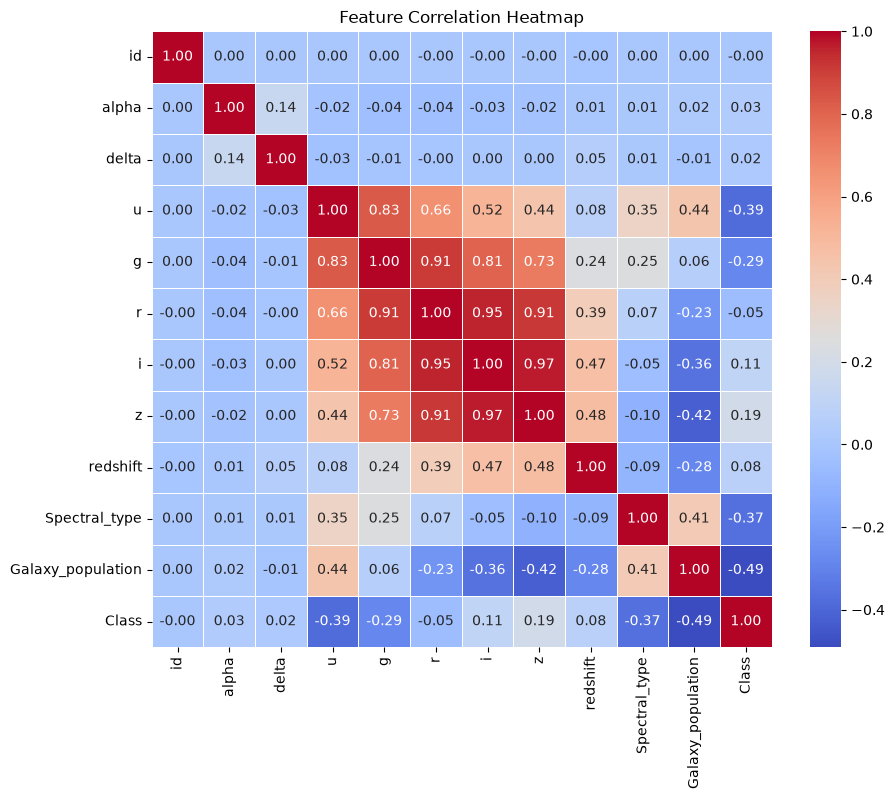

In [18]:
corr_matrix = train_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5
)
plt.title('Feature Correlation Heatmap')
plt.show()

In [19]:
train_df.drop(
    columns=[
        'id',
        'alpha',
        'delta',
        'g',
        'r',
        'i',
        'redshift'
    ],
    inplace=True
)

train_df

train_df



,u,z,Spectral_type,Galaxy_population,Class
0,25.472123,18.621057,2,1,0
1,20.778509,16.786433,2,1,0
2,21.035203,20.557366,3,0,1
3,23.305056,17.914952,2,1,0
4,21.703158,17.616185,2,1,0
...,...,...,...,...,...
577342,20.828729,16.551356,2,1,0
577343,23.734743,18.947275,2,1,0
577344,21.944250,18.203397,2,1,0
577345,21.969881,21.478134,1,0,1


In [20]:
X = train_df.drop(['Class'], axis='columns')
y = train_df['Class']

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [25]:
import xgboost as xgb

In [26]:
from sklearn.metrics import accuracy_score, classification_report

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=y_train.nunique(),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_pca,
    y_train,
    eval_set=[(X_test_pca, y_test)],
    verbose=False
)



,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor

In [27]:
# Copy test data and apply the same preprocessing as the training data
test_processed = test_df.copy()

# Use the same label mappings as training
spectral_mapping = {
    'A/F': 0,
    'G/K': 1,
    'M': 2,
    'O/B': 3
}

galaxy_mapping = {
    'Blue_Cloud': 0,
    'Red_Sequence': 1
}

test_processed['Spectral_type'] = test_processed['spectral_type'].map(
    spectral_mapping
)
test_processed['Galaxy_population'] = test_processed['galaxy_population'].map(
    galaxy_mapping
)

test_processed.drop(
    columns=[
        'spectral_type',
        'galaxy_population',
        'id',
        'alpha',
        'delta',
        'redshift'
    ],
    inplace=True
)

# Ensure feature order matches training data
test_processed = test_processed[X.columns]

# Scale and apply the fitted PCA transformation
test_scaled = scaler.transform(test_processed)
test_pca = pca.transform(test_scaled)

# Predict encoded classes
predicted_encoded = xgb_model.predict(test_pca).astype(int)

# Convert encoded labels back to original class names
predicted_classes = le.inverse_transform(predicted_encoded)

# Export predictions
prediction_df = pd.DataFrame({
    'id': test_df['id'],
    'class': predicted_classes
})

prediction_df.to_csv('predictions2.csv', index=False)

prediction_df.head()

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
